#### Import Libraries

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import marineHeatWaves as mhw
import datetime as dt
import math

import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
from rasterio.transform import from_origin

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
## options

BLyearstart = 1982
BLyearend = 2024
recalculateBL = False

#### Define Slice Function

The coordinates have to be defined in 0-360 format.

def spatial_subset(ds):
    out = ds.sel(lon = slice(347.0, 354.5),
                 lat = slice(34.5, 46.5))
    return out

## Get Baseline

In [3]:
if recalculateBL:
    baseline_df = pd.DataFrame()
    temp = xr.open_dataset(r"D:\sst_merged_big_box_IbPen.nc", 
                        engine="netcdf4", decode_times=True)
    
    temp_sel = temp #spatial_subset(temp)
    
    temp_sst = temp_sel["sst"]

    baseline_df = temp_sst.to_dataframe()

    baseline_df.reset_index(inplace= True)

    baseline_df.to_pickle(f'baseline.pkl')


In [4]:
baseline_df = pd.read_pickle('baseline.pkl')

## Conversion to ordinal time

In [5]:
def to_ordinal(time_array):
    ordinals = []

    for t in time_array:
        # Case 1: numpy.datetime64
        if isinstance(t, np.datetime64):
            ts = pd.Timestamp(t)
            ordinals.append(ts.to_pydatetime().date().toordinal())

        # Case 2: cftime objects
        else:
            ordinals.append(dt.date(t.year, t.month, t.day).toordinal())

    return np.array(ordinals)

## Detect MHWs

In [ ]:
class Analyse:
    def __init__(self):
        self.oisst = xr.open_dataset(r"D:\sst_merged_big_box_IbPen.nc",
                                    engine="netcdf4",
                                    decode_times=True)
        self.sliced = self.slice()

        self.results = self.detect_MHW()
        
        self.table = self.create_table()

        self.table.to_excel('mhwSummaryIbPen.xlsx')


    def slice(self):
        print('Slicing OISST Data')
    
        oisst_sel = self.oisst #spatial_subset(self.oisst)
        oisst_sst = oisst_sel["sst"]
        df = oisst_sst.to_dataframe().reset_index()
        df = df.dropna(subset=['sst'])
        df["year"] = pd.to_datetime(df["time"]).dt.year

        return df
    
    
    def detect_MHW(self, climatology_period=(BLyearstart, BLyearend)):
        print('Detecting MHWs')

        results = []

        grouped = self.sliced.groupby(["lat", "lon"])
        baseline_groups = baseline_df.groupby(["lat", "lon"])

        for (lat, lon), group in grouped:
            print(lat, lon)
            # --- main time series ---
            sst = group["sst"].values
            time = group["time"].values
            time_ord = to_ordinal(time)

            # --- baseline ---
            try:
                base_group = baseline_groups.get_group((lat, lon))
            except KeyError:
                continue

            base_sst = base_group["sst"].values
            base_time = base_group["time"].values
            base_time_ord = to_ordinal(base_time)

            sst = sst.copy()

            # --- detect MHW ---
            mhw_ev, clim = mhw.detect(
                time_ord,
                sst,
                climatologyPeriod=list(climatology_period),
                alternateClimatology=[base_time_ord, base_sst]
            )

            if mhw_ev["n_events"] == 0:
                continue

            for i in range(mhw_ev["n_events"]):
                results.append({
                    "year": mhw_ev["date_start"][i].year,
                    "lat": lat,
                    "lon": lon,
                    "duration": mhw_ev["duration"][i],
                    "max_intensity": mhw_ev["intensity_max"][i],
                    "mean_intensity": mhw_ev["intensity_mean"][i],
                    "cumulative_intensity": mhw_ev["intensity_cumulative"][i],
                })

        return pd.DataFrame(results)
    

    def create_table(self):
        print('Creating Table')
        table = self.results.drop(columns=['lat', 'lon']).groupby(by= 'year').agg(['min', 'max', 'mean', 'std'])
        table[('n_events', 'mean')] = self.results.groupby(['lat', 'lon', 'year']).size().groupby('year').mean()
        table[('n_events', 'total')] = self.results.groupby('year').size()
        return table

In [9]:
a = Analyse()

Slicing OISST Data
Detecting MHWs
34.625 347.125
34.625 347.375
34.625 347.625
34.625 347.875
34.625 348.125
34.625 348.375
34.625 348.625
34.625 348.875
34.625 349.125
34.625 349.375
34.625 349.625
34.625 349.875
34.625 350.125
34.625 350.375
34.625 350.625
34.625 350.875
34.625 351.125
34.625 351.375
34.625 351.625
34.625 351.875
34.625 352.125
34.625 352.375
34.625 352.625
34.625 352.875
34.625 353.125
34.625 353.375
34.875 347.125
34.875 347.375
34.875 347.625
34.875 347.875
34.875 348.125
34.875 348.375
34.875 348.625
34.875 348.875
34.875 349.125
34.875 349.375
34.875 349.625
34.875 349.875
34.875 350.125
34.875 350.375
34.875 350.625
34.875 350.875
34.875 351.125
34.875 351.375
34.875 351.625
34.875 351.875
34.875 352.125
34.875 352.375
34.875 352.625
34.875 352.875
34.875 353.125
34.875 353.375
34.875 353.625
35.125 347.125
35.125 347.375
35.125 347.625
35.125 347.875
35.125 348.125
35.125 348.375
35.125 348.625
35.125 348.875
35.125 349.125
35.125 349.375
35.125 349.625
35.125

In [ ]:
a.results["year"].unique()

array([1970], dtype=int32)

In [11]:
import pickle

with open("mhw_IbPen.pkl", "wb") as f:
    pickle.dump(a, f)

In [ ]:
with open("mhw_IbPen.pkl", "rb") as f:
    a = pickle.load(f)

In [36]:
import seaborn as sns
df = a.table.reset_index()

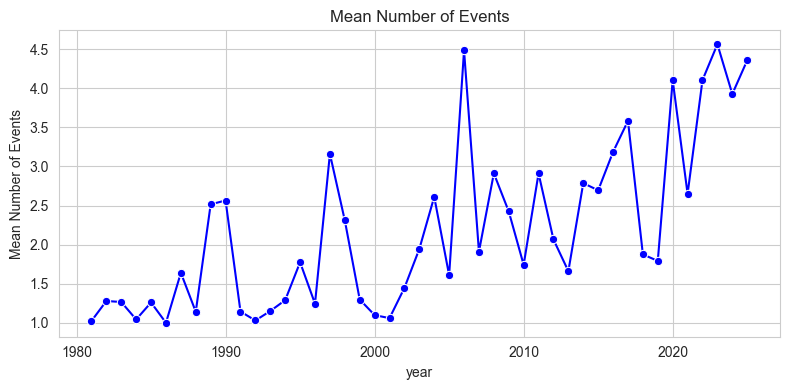

In [39]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(1,1, figsize=(8, 4))

sns.lineplot(df, y= ('n_events', 'mean'), x= 'year', ax= ax, color='blue', marker= 'o')

ax.set_ylabel('Mean Number of Events')


ax.set_title('Mean Number of Events')


plt.tight_layout()

plt.show()

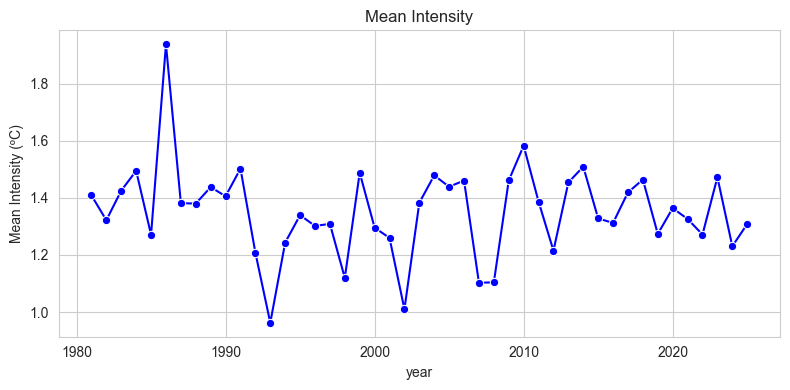

In [24]:
sns.set_style("whitegrid")
fig, ax = plt.subplots(1,1, figsize=(8, 4))

sns.lineplot(df, y= ('mean_intensity', 'mean'), x= 'year', ax= ax, color='blue', marker= 'o')

ax.set_ylabel('Mean Intensity (ºC)')


ax.set_title('Mean Intensity')


plt.tight_layout()

plt.show()

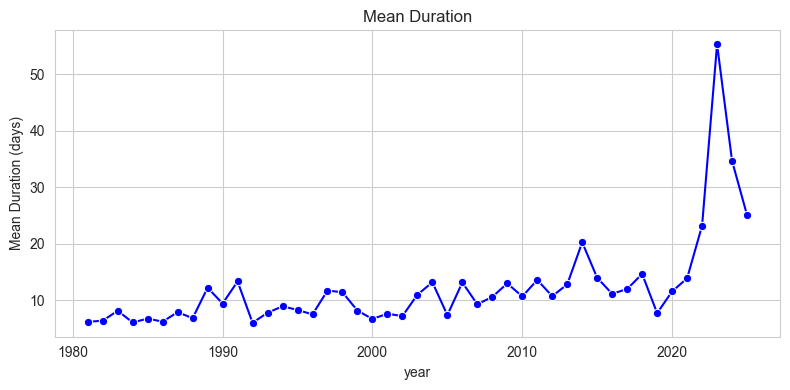

In [26]:
fig, ax = plt.subplots(1,1, figsize=(8, 4))

sns.lineplot(df, y= ('duration', 'mean'), x= 'year', ax= ax, color='blue', marker= 'o')


ax.set_ylabel('Mean Duration (days)')

ax.set_title('Mean Duration')

plt.tight_layout()

plt.show()

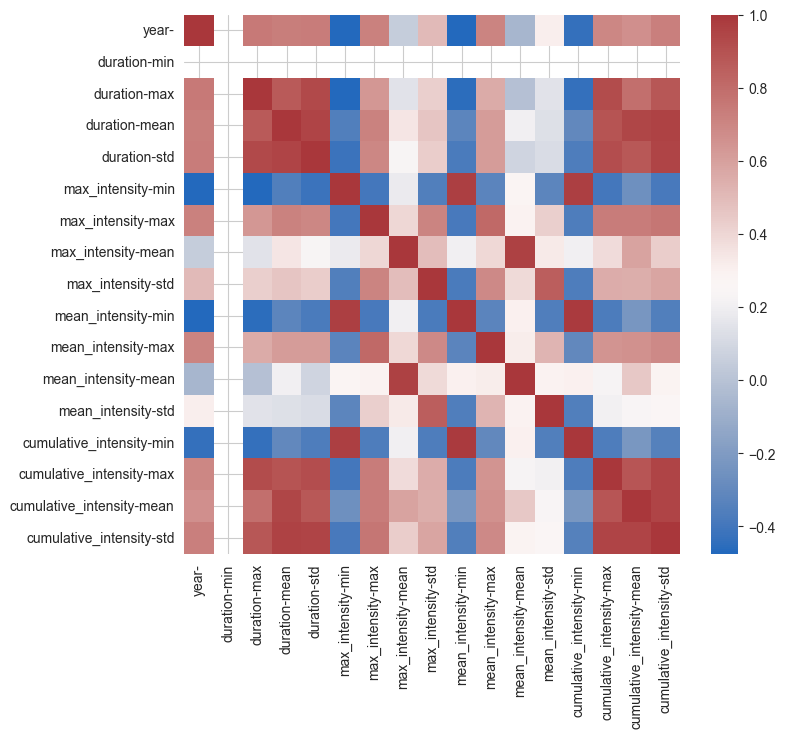

In [ ]:
fig, ax = plt.subplots( figsize=(8, 7), sharex= True)

sns.heatmap(df.corr('spearman'), cmap= 'vlag', ax= ax)


ax.set_xlabel('')


ax.set_ylabel('')


plt.show()